# Tema 7: Perceptron multistrat antrenat cu Pytorch

## Descrierea temei
Implementati un model de perceptron multistrat pentru clasificarea celor 10 clase din setul [Fashion MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist).

Puteti reutiliza si adapta cod din exemplul Pytorch pentru regresia logistica binara, din tema 5 (săptămâna 19 noiembrie - 25 noiembrie, de pe platforma elearning).

Modificarile pe care trebuie sa le aveti in vedere sunt:
1. In definirea lui Dataset nu se mai face filtrare dupa clasele pozitive si negative; se lasa toate datele
1. Functia de eroare `loss_fn` este `torch.nn.CrossEntropyLoss`.



## Suplimentar (si obligatoriu)
1. Pe un alt grafic sa se prezinte: accuratetea pe setul de antrenare si pe setul de testare, la finalul fiecarei epoci (ambele scoruri pe acelasi grafic, cu legenda).
1. Sa se calculeze si afiseze matricea de confuzie (puteti folosi [scikit learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)).

## Suplimentar (optional)

1. Pe un grafic sa se prezinte loss-ul la finalul fiecarei epoci, pe setul de antrenare. Functia de loss este aceeasi ca in logistic regression, cazul multinomial
1. Implementati modificare de ponderi folosind metoda momentum.
1. Matricea de confuzie ca procent + colorare heatmap.

# Predarea temei

Predarea acestei aplicatii se va face  in săptămâna  **18-22 decembrie**, în seara dinaintea laboratorului, ora 20, in cadrul temei 7 de pe platforma.
Cerinte si precizari:
1. Studentii se pot consulta intre ei, dar rezolvarile vor fi individuale. Necunoasterea codului prezentat inseamna nota 1 pentru tema curenta.

2. Se se faca adnotari de tipuri pentru variabilele folosite, parametrii de intrare ai functiilor si tipurile de retur. Neindeplinirea acestei cerinte duce la injumatatirea notei.

# Implementarea temei
# Importul bibliotecilor și setarea dispozitivului (CPU / GPU)
Importăm PyTorch și bibliotecile necesare, alegem device-ul pentru antrenare.

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install matplotlib
!pip install torch-summary
!pip install tensorboard

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl (73 kB)



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
      --------------------------------------- 0.1/5.5 MB 1.3 MB/s eta 0:00:05
     - -------------------------------------- 0.1/5.5 MB 1.7 MB/s eta 0:00:04
     - -------------------------------------- 0.2/5.5 MB 1.8 MB/s eta 0:00:03
     - -------------------------------------- 0.3/5.5 MB 1.6 MB/s eta 0:00:04
     --- ------------------------------------ 0.4/5.5 MB 2.2 MB/s eta 0:00:03
     --- ------------------------------------ 0.5/5.5 MB 2.2 MB/s eta 0:00:03
     ---- ----------------------------------- 0.6/5.5 MB 2.3 MB/s eta 0:00:03
     ---- ----------------------------------- 0.6/5.5 MB 1.9 MB/s eta 0:00:03
     ---- ----------------------------------- 0.7/5.5 MB 1.9 MB/s eta 0:00:03
     ----- ---------------------------------- 0.8/5.5 MB 1.9 MB/s eta 0:00:03
     ------ --------------------------------- 0.9/5.5 MB 1.9 MB/s eta 0:00:03
     ------- -------------------------------- 1.0/5.5 MB 2.1 MB/s eta 0


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from typing import Tuple
from typing import Final
from typing import List

import numpy as np
import matplotlib.pyplot as plt

device : Final[torch.device] = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using PyTorch version: {torch.__version__} | Device: {device}")

Using PyTorch version: 2.5.1+cu118 | Device: cpu


In [3]:
!pip install torch-summary


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from torchsummary import summary

# Pregatirea setului de date: clasa de tip Dataset
## Încărcarea setului de date Fashion-MNIST și transformarea imaginilor

Descărcăm datasetul, convertim imaginile la tensori și pregătim Data-loaderele pentru batch-uri.

In [5]:
# importam clasa de baza Dataset:
from torch.utils.data import Dataset

In [6]:
from torch.utils.data import DataLoader

transform : transforms.ToTensor = transforms.ToTensor()

train_ds : datasets.FashionMNIST  = datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)
test_ds : datasets.FashionMNIST =datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)

In [7]:
batch_size : int = 32
train_loader : DataLoader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader : DataLoader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

data: torch.Tensor
label: torch.Tensor
for data, label in train_loader:
    print(data.shape, label.shape)
    break

torch.Size([32, 1, 28, 28]) torch.Size([32])


# Vizualizarea unor exemple (eșantioane) din setul de antrenare

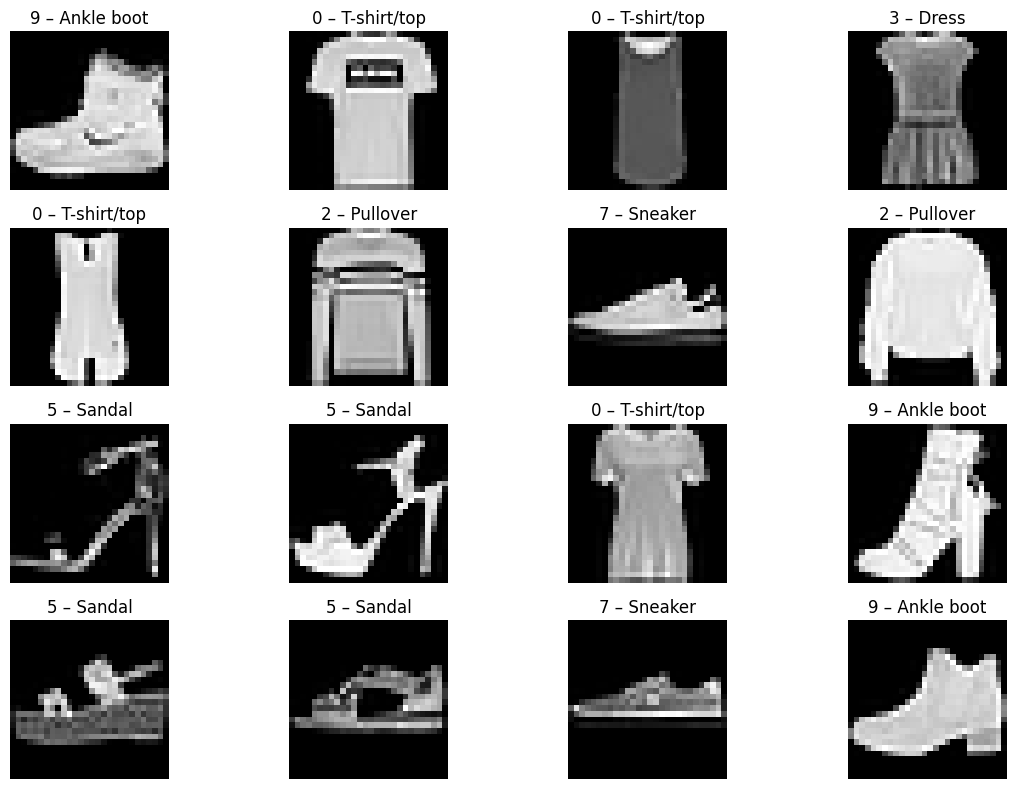

In [8]:
fashion_mnist_labels : list[str] = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def show_samples_torch(dataset : Dataset, n_samples : int = 16) -> None:

  fig : plt.Figure
  ax : np.ndarray
  fig,ax = plt.subplots(n_samples // 4, 4, figsize=(12,8))

  k : int
  for k in range(n_samples):
    row: int
    col : int
    x : torch.Tensor
    y : int
    row,col = k // 4, k % 4
    x, y = dataset[k]
    img : torch.Tensor = x.squeeze(0)
    label_name : str =fashion_mnist_labels[y]
    ax[row, col].imshow(img, cmap='gray')
    ax[row, col].set_title(f"{y} – {label_name}")
    ax[row, col].axis("off")

  plt.tight_layout()
  plt.show()

show_samples_torch(train_ds, n_samples=16)

# Definirea modelului Perceptron Multistrat (MLP)

Model feed-forward cu două straturi ascunse și activări ReLU.

In [9]:
class MLP(nn.Module):
  def __init__(self, input_size: int = 784 , hidden_layers: List[int] = [256,128], num_classes : int = 10) -> None:
    super(MLP, self).__init__()
    layers : List[nn.Module] = []
    prev_size : int = input_size

    h : int
    for h in hidden_layers:
      layers.append(nn.Linear(prev_size, h))
      layers.append(nn.ReLU())
      prev_size = h

    layers.append(nn.Linear(prev_size, num_classes))
    self.net : nn.Sequential = nn.Sequential(*layers)

  def forward(self, x : torch.Tensor) -> torch.Tensor:
    x = x.view(x.size(0), -1)
    return self.net(x)

model : MLP = MLP(hidden_layers=[256,128]).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


#Verificarea modelului MLP și a dimensiunilor ieșirii pe un batch de date

Înainte de antrenare verificăm că modelul funcționează și returnează scoruri (logits) cu forma (batch_size, 10).

Batch size implicit este 32, deci forma așteptată este torch.Size([32, 10]).

In [10]:
x: torch.Tensor
y: torch.Tensor

x, y = next(iter(train_loader))
x = x.to(device)

logits : torch.Tensor = model(x)
print(logits.shape)

torch.Size([32, 10])


In [11]:
summary(model, input_size=(1, 28, 28), device=str(device));

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       200,960
|    └─ReLU: 2-2                         --
|    └─Linear: 2-3                       32,896
|    └─ReLU: 2-4                         --
|    └─Linear: 2-5                       1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0


# Definirea funcției de pierdere și a optimizer-ului (SGD + momentum)
Pentru clasificare multi-clasă folosim CrossEntropyLoss.

In [12]:
loss_fn : nn.CrossEntropyLoss = nn.CrossEntropyLoss()
optimizer : torch.optim.Optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

# Funcție de calculare a acurateței pe un DataLoader

Evaluăm performanța modelului pe antrenare / testare.

In [13]:
def accuracy_torch(model: nn.Module, data_loader: DataLoader, device: torch.device) -> float:
  model.eval()
  correct : int = 0
  total : int = 0

  with torch.no_grad():

    x: torch.Tensor
    y: torch.Tensor
    for x,y in data_loader:
        x=x.to(device)
        y=y.to(device)

        logits : torch.Tensor = model(x)
        preds : torch.Tensor = torch.argmax(logits, dim=1)
        correct += torch.sum(preds==y).item()
        total += y.size(0)

  return 100.0 * correct / total

# Bucla de antrenare pe epoci + colectarea matricei

Antrenăm modelul, calculăm loss-ul, salvăm accuracy-ul pentru plotare.

In [ ]:
epochs : int = 20

train_acc_list : list[float] = []
test_acc_list : list[float] = []
train_loss_list : list[float] = []

epoch : int
for epoch in range(epochs):
    model.train()
    running_loss : float = 0.0

    x : torch.Tensor
    y : torch.Tensor
    for x,y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits : torch.Tensor = model(x)
        loss : torch.Tensor = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss : float = running_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    train_acc : float = accuracy_torch(model, train_loader, device)
    test_acc : float = accuracy_torch(model, test_loader, device)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(
    f"Epoch {epoch+1}/{epochs} | "
    f"Loss: {avg_loss:.4f} | "
    f"Train acc: {train_acc:.2f}% | "
    f"Test acc: {test_acc:.2f}%"
)

Epoch 1/20 | Loss: 1.0721 | Train acc: 78.16% | Test acc: 77.18%
Epoch 2/20 | Loss: 0.5701 | Train acc: 81.31% | Test acc: 80.34%
Epoch 3/20 | Loss: 0.4942 | Train acc: 83.06% | Test acc: 81.77%
Epoch 4/20 | Loss: 0.4615 | Train acc: 84.64% | Test acc: 83.15%
Epoch 5/20 | Loss: 0.4384 | Train acc: 85.41% | Test acc: 83.73%


# Acuratețea pe setul de antrenare și testare (grafic)

Grafic comparativ după fiecare epocă.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_acc_list, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), test_acc_list, label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy per epoch')
plt.legend()
plt.grid(True)
plt.show()

# Matricea de confuzie absolută pe setul de testare

Analizăm distribuția clasificărilor corecte și greșite.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds : list[int] = []
all_true : list[int] = []

with torch.no_grad():
  for x,y in test_loader:
    x : torch.Tensor = x.to(device)
    y : torch.Tensor = y.to(device)
    logits : torch.Tensor = model(x)
    preds : torch.Tensor = torch.argmax(logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_true.extend(y.cpu().numpy())

cm : np.ndarray = confusion_matrix(all_true, all_preds)

labels_names : list[str] = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels_names,
            yticklabels=labels_names,
            linewidths=0.5,
            cbar_kws={'label': 'Number of Samples'})

plt.title('Fashion MNIST Confusion Matrix\n(10 classes of clothing)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Matricea de confuzie în procente (heatmap colorat)

Matrice normalizată pe linii — arată precizia modelului pe fiecare clasă.

In [ ]:
cm_percent : np.ndarray = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))

sns.heatmap(cm_percent,
            annot=True,
            fmt=".1f",
            cmap='Blues',
            xticklabels=labels_names,
            yticklabels=labels_names,
            linewidths=0.5,
            cbar_kws={'label': 'Percentage (%)'})

plt.title('Fashion MNIST Confusion Matrix\n(10 classes of clothing)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Pierderea (loss-ul) pe setul de antrenare (grafic)

Vizualizăm evoluția loss-ului pe epoci.

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1, epochs+1), train_loss_list, marker='o', color='blue')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)
plt.show()